# Introduction
## Diffusion Equation
The 1D diffusion equation is given by
$$\frac{\partial u(x,t)}{\partial t} = \nu \frac{\partial^2 u(x,t)}{\partial x^2},$$
where
- $u(x,t)$ is the function we're tracking (velocity, temperature, etc)
- $x$ is position
- $t$ is time
- $\nu$ is the diffusion coefficient, ie how fast things spread

## Discretised Laplacian
The central second difference approximation
$$
\frac{d^2u(x_i)}{dx^2}\approx\frac{u_{i+1}-2u_i+u_{i-1}}{h^2}
$$
is used to form the Laplacian matrix
$$
L = \frac{1}{h^2}\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 \\
1 & -2 & 1 & 0 & 0 \\
0 & 1 & -2 & 1 & 0 \\ 
0 & 0 & 1 & -2 & 1 \\
0 & 0 & 0 & 1 & -2
\end{pmatrix}
$$
where we have assumed dirichlet (non-periodic) boundary conditions.

## Time-Stepping Operator (CHANGE TO SECOND OR THIRD ORDER)
The time-stepping operator
$$
A = \mathbb I + \nu dt \  L
$$
is the operator that carries out the time evolution in steps using the Forward Euler scheme.

## Generating the Laplacian MPO


## Time Evolution using Tensor Networks
In the dense case, the state vector is updated by repeatedly applying the time-step operator
$$
\mathbf u(t_{i+1})=A  \mathbf u(t_i).
$$

In the tensor network formulation, $A$ and $\mathbf u(t_0)$ are converted into an MPO and an MPS respectively. The same update rule is performed in the tensor network language, which is to contract the MPO with the MPS to obtain the next update.

After each update, the resulting MPS is compressed via SVD truncation to limit bond dimension.

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import quimb.tensor as qtn
import time

# Helper Functions

In [33]:
# ============
# DENSE SOLVER
# ============

def laplacian_1d_dense_periodic(N, dx):
    L = np.zeros((N, N))
    for i in range(N):
        L[i, i] = -2.0
        L[i, (i - 1) % N] = 1.0
        L[i, (i + 1) % N] = 1.0
    return L / (dx * dx)


def evolve_dense_complex(u0, steps, A1, A2, dt, save_every=50):
    u = u0.copy()

    saved = []
    times = []
    norms = []

    t = 0.0
    
    for i in range(steps):
        # save current state
        if i % save_every == 0:
            saved.append(u.copy())
            times.append(t)
            norms.append(np.linalg.norm(u))
    
        # advance one timestep
        u = A1 @ u
        u = A2 @ u
        t += dt
    
    # save final state
    saved.append(u.copy())
    times.append(t)
    norms.append(np.linalg.norm(u))
    
    return np.array(times), np.array(saved), np.array(norms)

def evolve_dense(u0, steps, A, dt, save_every=50):
    u = u0.copy()

    saved = []
    times = []
    norms = []

    t = 0.0
    
    for i in range(steps):
        # save current state
        if i % save_every == 0:
            saved.append(u.copy())
            times.append(t)
            norms.append(np.linalg.norm(u))
    
        # advance one timestep
        u = A @ u
        t += dt
    
    # save final state
    saved.append(u.copy())
    times.append(t)
    norms.append(np.linalg.norm(u))
    
    return np.array(times), np.array(saved), np.array(norms)



# ==================
# MPS/MPO GENERATION
# ==================

# these helper functions convert from vectors to MPS and vice versa,
# as well as from matrices to MPOs

def vec_to_qtt_mps(u, n, cutoff=1e-10, max_bond=64):
    T = u.reshape((2,) * n)
    mps = qtn.MatrixProductState.from_dense(T, cutoff=cutoff, max_bond=max_bond)
    return mps

def qtt_mps_to_vec(mps):
    T = mps.to_dense()
    return np.asarray(T).reshape(-1)

def mat_to_qtt_mpo(A, n, cutoff=1e-12, max_bond=256):
    return qtn.MatrixProductOperator.from_dense(
        A, dims=[2] * n, cutoff=cutoff, max_bond=max_bond
    )


# ====================
# TIME EVOLUTION IN TN
# ====================

def step_mps(mps, mpo, cutoff=1e-10, max_bond=64):
    mps_new = mpo.apply(mps)
    mps_new.compress(cutoff=cutoff, max_bond=max_bond)
    return mps_new

def evolve_mps(mps0, mpoA, steps, save_every=50, cutoff=1e-10, max_bond=64):
    mps = mps0.copy()
    saved = []
    bonds = []
    
    for i in range(steps):
        if i % save_every == 0:
            saved.append(mps.copy())
            bonds.append(max(mps.bond_sizes()))
    
        mps = step_mps(mps, mpoA, cutoff, max_bond)
    
    # save final state
    saved.append(mps.copy())
    bonds.append(max(mps.bond_sizes()))
    return saved, bonds



# =======================================
# WRAPPER FUNCTIONS TO MEASURE TIME TAKEN
# =======================================

def time_initialisation_complex(N, dx, dt, nu):
    t0 = time.perf_counter()
    L = laplacian_1d_dense_periodic(N, dx).astype(np.complex128)

    a1 = (1 - 1j) / 2
    a2 = (1 + 1j) / 2
    A1 = np.eye(N, dtype=np.complex128) + a1 * dt * nu * L
    A2 = np.eye(N, dtype=np.complex128) + a2 * dt * nu * L

    t1 = time.perf_counter()
    return A1, A2, t1 - t0

def time_initialisation(N, dx, dt, nu):
    t0 = time.perf_counter()
    L = laplacian_1d_dense_periodic(N, dx)
    A = np.eye(N, dtype=np.complex128) + dt * nu * L
    t1 = time.perf_counter()
    return L, A, t1 - t0

def time_mps_construction(u0, n, cutoff, max_bond):
    t0 = time.perf_counter()
    mps0 = vec_to_qtt_mps(u0, n, cutoff, max_bond)
    t1 = time.perf_counter()
    return mps0, t1 - t0

def time_mpo_construction(A, n, mpo_cutoff, mpo_max_bond):
    t0 = time.perf_counter()
    mpoA = mat_to_qtt_mpo(A, n, mpo_cutoff, mpo_max_bond)
    t1 = time.perf_counter()
    return mpoA, t1 - t0

def time_evolve_dense(u0, steps, A, dt, save_every=50):
    t0 = time.perf_counter()
    times, us, norms = evolve_dense(u0, steps, A, dt, save_every)
    t1 = time.perf_counter()
    return times, us, norms, t1 - t0

def time_evolve_dense_complex(u0, steps, A1, A2, dt, save_every=50):
    t0 = time.perf_counter()
    times, us, norms = evolve_dense_complex(u0, steps, A1, A2, dt, save_every)
    t1 = time.perf_counter()
    return times, us, norms, t1 - t0

def time_evolve_mps(mps0, mpoA, steps, save_every=50, cutoff=1e-10, max_bond=64):
    t0 = time.perf_counter()
    mps_saved, bond_track = evolve_mps(mps0, mpoA, steps, save_every, cutoff, max_bond)
    t1 = time.perf_counter()
    return mps_saved, bond_track, t1 - t0

# Parameters

In [ ]:
# ==================
# GENERAL PARAMETERS
# ==================

n = 9
total_time = 5             # number of steps required for time evolution
u0_type = "sines"         # "sines" | "quadratic" | "random"

nu = 1e-3                 # diffusion coefficient 
save_every = 200          # after this many steps, take a snapshot of the function to plot on the graph
cfl = 0.1                 # controls time step relative to grid spacing. affects stability of time0-step scheme



# =============
# TN PARAMETERS
# =============

# parameters for forming the initial MPS
mps_cutoff = 1e-12
mpo_max_bond = 64

# parameters for forming the initial MPO
mpo_cutoff = 1e-12
mpo_max_bond = 256

# Set Up

In [ ]:
N     = 2**n
x     = np.linspace(0, 1, N, endpoint=False)
dx    = x[1] - x[0] 


if u0_type == "sines":
    u0 = np.sin(2*np.pi*2*x) + 0.5*np.sin(2*np.pi*7*x)
elif u0_type == "quadratic":
    u0 = x**2
elif u0_type == "random":
    u0 = np.random.randn(N)
else:
    u0 = np.asarray(u0_type)

cfls = [0.2, 0.1, 0.05, 0.025, 0.0125]

errors_euler = []
errors_lpe2  = []
dts = []

for cfl in cfls:
    dt    = cfl * dx*dx / nu 
    steps = int(total_time / dt)
    print("steps =", steps)

    L, A, t_init = time_initialisation(N, dx, dt, nu)
    times, us, norms, t_evolve_dense = time_evolve_dense(u0, steps, A, dt, save_every)

    A1, A2, t_init_complex   = time_initialisation_complex(N, dx, dt, nu) # initialise laplacian matrix L and time-stepping operator A
    times_complex, us_complex, norms_complex, t_evolve_dense_complex    = time_evolve_dense_complex(u0, steps, A1, A2, dt, save_every)

    u_exact = la.expm(steps * dt * nu * L) @ u0
    error_euler = np.linalg.norm(us[-1] - u_exact)
    error_lpe2 = np.linalg.norm(us_complex[-1] - u_exact) # extracting the final state of the MPS after time evolution via both methods and comparing with exact solution

    errors_euler.append(error_euler)
    errors_lpe2.append(error_lpe2)
    dts.append(dt)
    
    print("max imag part LPE2:", np.max(np.abs(us_complex[-1].imag)))


steps = 6553
max imag part LPE2: 1.942890293094024e-16
steps = 13107
max imag part LPE2: 1.754846268298138e-14
steps = 26214
max imag part LPE2: 1.3877787807814457e-16
steps = 52428
max imag part LPE2: 1.3877787807814457e-16
steps = 104857
max imag part LPE2: 2.7313221129254828e-15


pair 0: Euler order ≈ 1.000, LPE2 order ≈ 1.998
pair 1: Euler order ≈ 1.000, LPE2 order ≈ 2.030
pair 2: Euler order ≈ 1.000, LPE2 order ≈ 2.087
pair 3: Euler order ≈ 1.000, LPE2 order ≈ 0.490


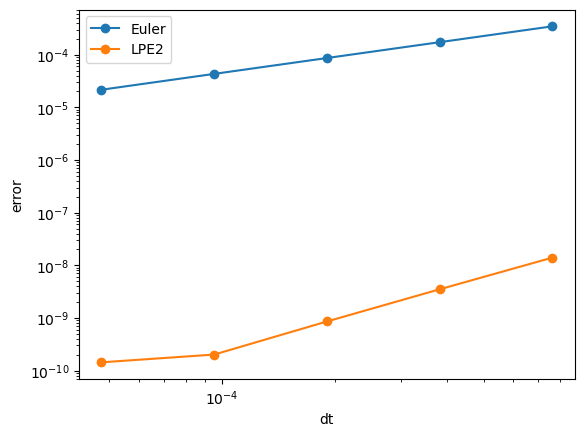

In [44]:
plt.loglog(dts, errors_euler, 'o-', label='Euler')
plt.loglog(dts, errors_lpe2, 'o-', label='LPE2')
plt.xlabel("dt")
plt.ylabel("error")
plt.legend()

for i in range(len(dts) - 1):
    p_euler = np.log(errors_euler[i] / errors_euler[i+1]) / np.log(dts[i] / dts[i+1])
    p_lpe2  = np.log(errors_lpe2[i]  / errors_lpe2[i+1])  / np.log(dts[i] / dts[i+1])

    print(f"pair {i}: Euler order ≈ {p_euler:.3f}, LPE2 order ≈ {p_lpe2:.3f}")